# Exercises to Statistical Methods and Analysis Techniques in Experimental Physics
## Exercise 2, March 4th, 2025

## 1) Uncertainties

A semiconductor is a material that conducts electricity more or less well depending on the temperature. In this experiment, you want to measure the so-called band-gap energy as a function of temperature of a semi-conductor, i.e. the amount of energy required to move an electron from the valence band to the conduction band. You can measure the tension $V$ and the current intensity $I$ of the electrical current going through the semi-conductor. Use the following formulas and the following measurement values to compute the resistance and band-gap energy with the correct propagated uncertainties.   

Plot the resistance and the band-gap energy as a function of temperature with the errorbars.

$$ R = V/I$$
$$E_\text{gap} \propto 2k_B T\ln R$$
with $k_B = 8.617333262145\cdot 10^{-5}$ ev/K

In [2]:
import numpy as np
import pandas as pd
from scipy.constants import zero_Celsius

T = np.arange(20., 610., 10.) + zero_Celsius 

V = np.array([1.67, 1.7,  1.74, 1.77, 1.79, 1.8, 1.82, 1.82, 1.81, 1.75, 1.65, 1.54, 1.41, 1.33, 1.28, 1.14, 1.02, 0.9, 0.79, 0.69, 0.6, 0.53, 0.47, 0.41, 0.37, 0.33, 0.3, 0.28, 0.26, 0.24, 0.22, 0.2, 0.19, 0.18, 0.16, 
              0.15, 0.14, 0.14, 0.13, 0.12, 0.11, 0.11, 0.1, 0.1, 0.09, 0.09, 0.09, 0.08, 0.08, 0.07, 0.07, 0.07, 0.07, 0.06, 0.06, 0.06, 0.06, 0.05, 0.05]) 

I = np.array([0.5433, 0.5552, 0.5122, 0.4744, 0.4443, 0.4202, 0.4071, 0.4172, 0.4755, 0.625, 0.896, 1.2977, 1.82, 2.35, 2.89, 3.68, 4.5, 5.45, 6.52, 7.7, 8.74, 9.88, 10.45, 12., 13.43, 14.75, 16.,      
                18.4, 20.6, 22.74, 24.96, 27.33, 29.75, 32.33, 35.03, 37.83, 40.74, 45.96, 48.21, 52.01, 55.97, 60.38, 64.84, 69.74, 74.74, 79.94, 85.4, 91.32, 96.34, 102.55, 109.46, 117.16, 123.76,  
                131.9, 138.08, 145.23, 153.9, 160.15, 167.81])/1000 

data = {
    'temperature': T,
    'tension': V,
    'intensity': I,
}

#uncertainties of the measurements
V_u = 0.01
I_u = 10e-5
T_u = 0.5

In [5]:
#print(f"Lengths of variables")
#for name, variable in data.items():
#    print(f"{name.rjust(15)}: {len(variable)}")

import math as m
import matplotlib.pyplot as plt
kB = 8.617333262145e-5

un_T = np.ones(len(data['temperature']))*T_u
un_V = np.ones(len(data['tension']))*V_u
un_I = np.ones(len(data['intensity']))*I_u
uncertainties = {
    'temperature': un_T,
    'tension': un_V,
    'intensity': un_I,
}

#There's no point in evaluating the covariant matrix since all these values are not extracted from the same distribution: each V,I is obained
#at a different temperature, meaning that the distribution of such values is different. It doesn't make sense to average them either!

R = np.zeros(len(data["tension"]))
un_R = np.zeros(len(data["tension"]))
E_gap = np.zeros(len(data["tension"]))
un_E_gap = np.zeros(len(data["tension"]))
i = 0
while i<len(data["tension"]):
    R[i] = data["tension"][i]/data["intensity"][i]
    un_R[i] = m.sqrt( (uncertainties["tension"][i]/data["intensity"][i])**2 + (data["tension"][i]/data["intensity"][i]**2*uncertainties["intensity"][i])**2 )
    #print(f"{R[i]} pm {un_R[i]}")
    E_gap[i] = 2*kB*data["temperature"][i]*m.log(R[i]) #energy gap expressed in electronvolt
    un_E_gap[i] = m.sqrt( (2*kB*uncertainties["temperature"][i]*m.log(R[i]))**2 + (2*kB*uncertainties["temperature"][i]/R[i]*un_R[i])**2 )
    #print(f"{E_gap[i]} pm {un_E_gap[i]}")
    i += 1
data["resistance"] = R
data["energy_gap"] = E_gap
uncertainties["resistance"] = un_R
uncertainties["energy_gap"] = un_E_gap

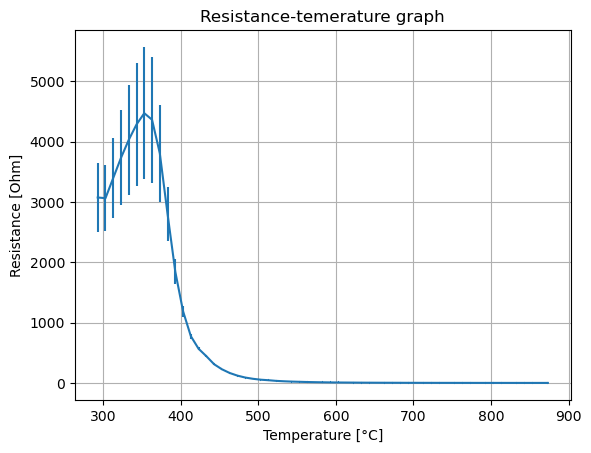

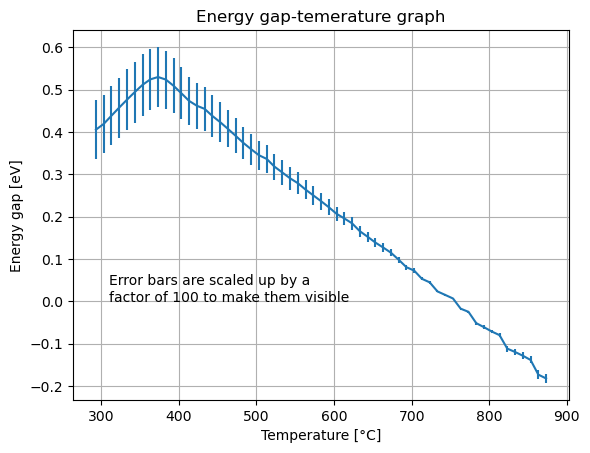

In [21]:
# Resistance-temerature graph
plt.errorbar(data["temperature"],data["resistance"],uncertainties['resistance'],uncertainties['temperature'])
plt.grid(1)
#plt.yscale("log")
plt.title("Resistance-temerature graph")
plt.xlabel("Temperature [°C]")
plt.ylabel("Resistance [Ohm]")
plt.show()

# Energy gap-temerature graph
plt.errorbar(data["temperature"],data["energy_gap"],uncertainties['energy_gap']*100,uncertainties['temperature'])
plt.grid(1)
plt.title("Energy gap-temerature graph")
plt.xlabel("Temperature [°C]")
plt.ylabel("Energy gap [eV]")
plt.text(310,0,"Error bars are scaled up by a\nfactor of 100 to make them visible")
plt.show()

## 2) Covariances and correlations

Assume an experiment where you measure the energy, momentum, temperature and mass of a particle.   
Assess the pairwise correlations of these properties. 

In [5]:
import numpy as np
import pandas as pd

E = np.array([1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])
p = np.array([0.5, 0.8, 1.0, 1.2, 1.4, 1.5, 1.8, 2.0])
t = np.array([300, 320, 330, 310, 325, 335, 340, 315])
m = np.array([0.5, 0.6, 0.7, 0.6, 0.8, 0.7, 0.75, 0.65])


raw = {
    'energy': E,
    'momentum': p,
    'temperature': t,
    'mass': m,
}

### 2.1) 
Compute the covariance and correlation factor of the parameters. 

In [6]:
names = []
for name in raw:
    names.append(name)
#print(names)

data = pd.DataFrame(raw)

In [7]:
def get_cov(obs1, obs2):
    """Evaluates the covariance between the set of data of two observables having the same length

    The two observables shall be passed to the function as lists, np.array or anything that is accepted by
    the function len and whose elements can be accessed through an integer index. It returns a number."""
    import numpy as np
    
    if len(obs1) != len(obs2):
        print("Inputs to get_cov have different lengths")
        return NaN

    mean1 = np.mean(obs1); mean2 = np.mean(obs2)
    N = len(obs1)
    
    cov = 0; i = 0
    while i < N:
        cov += (obs1[i]-mean1)*(obs2[i]-mean2)/N
        i += 1
        
    return cov

def get_cov_matrix(data):
    """Evaluates the covariance matrix of the data

    Data must be passed as pandas DataFrame where the columns all have the same length. It would be useful to
    assign proper names to the columns for better readability. It returns a DataFrame with labelled columns and
    indices."""
    import numpy as np
    import pandas as pd

    num_features = data.shape[1]
    cov_matrix = pd.DataFrame(np.zeros((num_features,num_features)), columns=data.columns.tolist(), index=data.columns.tolist())
    for feature1 in data:
        for feature2 in data:
            if cov_matrix.loc[feature2, feature1] != 0: #avoid evaluating twice the same covariance
                cov_matrix.loc[feature1, feature2] = cov_matrix.loc[feature2, feature1]
            else:
                cov_matrix.loc[feature1,feature2] = get_cov(data[feature1],data[feature2])

    return cov_matrix

def get_corr_factor_matrix(cov_matrix):
    """"Transforms a covariance matrix into a correlation factor matrix.

    The input must be a pandas DataFrame, the output will be a DataFrame as well"""
    import pandas as pd

    num_features = cov_matrix.shape[1]
    corr_factor_matrix = pd.DataFrame(np.zeros((num_features,num_features)), columns=cov_matrix.columns.tolist(), index=cov_matrix.columns.tolist())
    for feature1 in cov_matrix:
        for feature2 in cov_matrix:
            if (feature1==feature2)|(corr_factor_matrix.loc[feature2,feature1] != 0):
                corr_factor_matrix.loc[feature1,feature2] = corr_factor_matrix.loc[feature2,feature1]
            else:
                corr_factor_matrix.loc[feature1,feature2] = cov_matrix.loc[feature1,feature2]/(cov_matrix.loc[feature1,feature1]*cov_matrix.loc[feature2,feature2])**0.5

    return corr_factor_matrix

In [8]:
cov_matrix = get_cov_matrix(data)
corr_factor_matrix = get_corr_factor_matrix(cov_matrix)
print(cov_matrix,"\n\n",corr_factor_matrix)

              energy  momentum  temperature      mass
energy       1.31250  0.537500     7.343750  0.062500
momentum     0.53750  0.221875     3.046875  0.026563
temperature  7.34375  3.046875   155.859375  0.914062
mass         0.06250  0.026563     0.914062  0.007969 

                energy  momentum  temperature      mass
energy       0.000000  0.996035     0.513454  0.611132
momentum     0.996035  0.000000     0.518124  0.631713
temperature  0.513454  0.518124     0.000000  0.820190
mass         0.611132  0.631713     0.820190  0.000000


### 2.2)
Fill the energy and momentum into a 2D histogram with 5 bins on each axis, get the correlation and the covariance from the histogram and compare it with the calculated one. The difference with respect to (2.1) is that here your data are binned. Comment on the information loss from unbinned to binned data for the calculation of covariance/correlation and discuss the limit for which unbinned and binned data reach the same result. Note: getting correlation and covariance from the histogram means computing these quantities using the average values of the bins.

[]

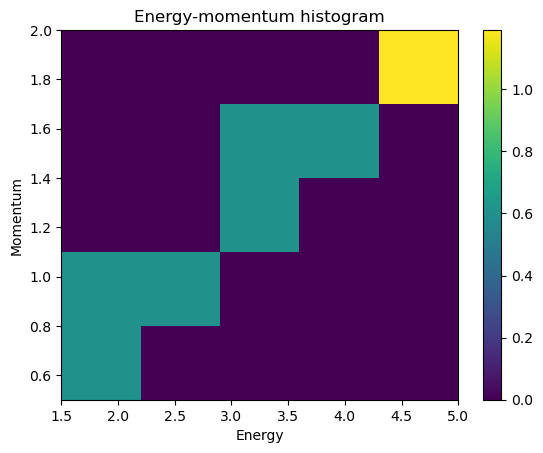

In [9]:
import matplotlib.pyplot as plt

plt.hist2d(data["energy"],data["momentum"], 5, density=1)
plt.colorbar()
plt.title("Energy-momentum histogram")
plt.xlabel("Energy")
plt.ylabel("Momentum")
plt.plot()

In [16]:
def get_bin_cov(obs1, obs2, nbin):
    """Evaluates the covariance between two observables splitting the data into nbin bins

    Both set of data are splitted in the same number of bins, which is the only way one can evaluate covariance"""
    import numpy as np
    
    min1 = np.min(obs1); max1 = np.max(obs1); bin_length1 = (max1-min1)/nbin; pos_bin1 = min1 + bin_length1/2 + range(nbin)*bin_length1
    min2 = np.min(obs2); max2 = np.max(obs2); bin_length2 = (max2-min2)/nbin; pos_bin2 = min2 + bin_length2/2 + range(nbin)*bin_length2

    binned_obs1 = np.zeros(len(obs1))
    i = 0
    while i < len(obs1):
        index = int((obs1[i]-min1)//bin_length1)
        if index==nbin:
            index += -1
        binned_obs1[i] = pos_bin1[index]
        i += 1

    binned_obs2 = np.zeros(len(obs2))
    i = 0
    while i < len(obs2):
        index = int((obs2[i]-min2)//bin_length2)
        if index==nbin:
            index += -1
        binned_obs2[i] = pos_bin2[index]
        i += 1

    return get_cov(binned_obs1,binned_obs2)

In [17]:
def get_bin_corr_factor(obs1, obs2, nbin):
    """Evaluates the correlation factor between two observables splitting the data into nbin bins

    The function relies on get_bin_conv to evaluate the covariance first. It also uses that function to get the
    variance of each set of data splitted into bins"""
    import math as m
    
    var1 = get_bin_cov(obs1, obs1, nbin)
    var2 = get_bin_cov(obs2, obs2, nbin)
    cov =  get_bin_cov(obs1, obs2, nbin)

    bin_corr_factor = cov/m.sqrt(var1*var2)

    return bin_corr_factor

In [18]:
nbin = 5
bin_cov = get_bin_cov(data["energy"],data["momentum"], nbin)
bin_corr_factor = get_bin_corr_factor(data["energy"],data["momentum"], nbin)
print(f"Energy-momentum covariance splitted in {nbin} bins:".ljust(50), f"{bin_cov}".ljust(20), f"correlation factor: {bin_corr_factor}")
print(f"Energy-momentum covariance unsplitted:".ljust(50), f"{cov_matrix.loc['energy','momentum']}".ljust(20), f"correlation factor: {corr_factor_matrix.loc['energy','momentum']}")
print("We see that splitting data into bins greatly reduces the covariance. This makes sense as the splitting into bins hides the correlations that occur within the same bin")

Energy-momentum covariance splitted in 5 bins:     0.42000000000000004  correlation factor: 0.9778117301634254
Energy-momentum covariance unsplitted:             0.5375000000000001   correlation factor: 0.996035063852612
We see that splitting data into bins greatly reduces the covariance. This makes sense as the splitting into bins hides the correlations that occur within the same bin


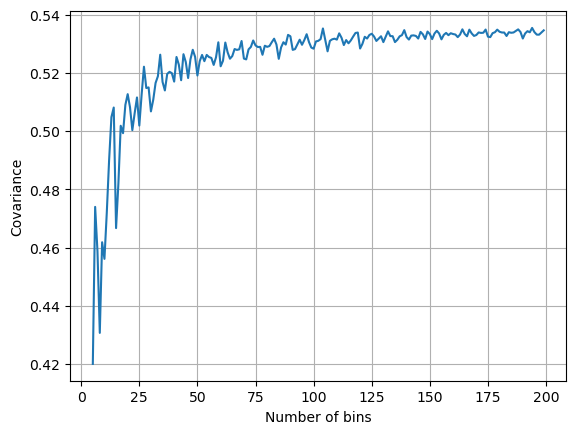

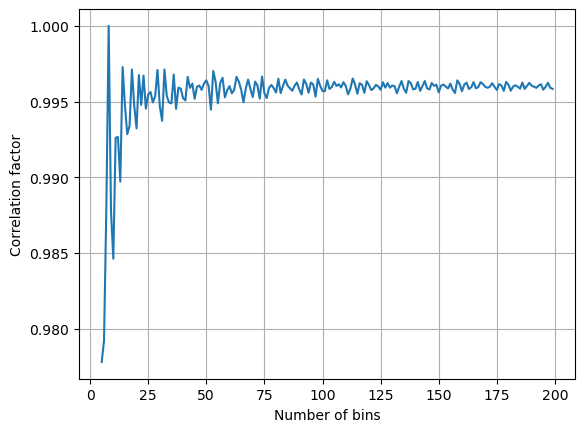

We can observe from the plotted graphs that the number of bins required to saturate to the same values of unbinned data is much higher than the number of data: roughly 125 bins are needed to obtain similar values of both covariance and correlation factor


In [23]:
import numpy as np
import matplotlib.pyplot as plt

nbin_array = range(5,200)
bin_cov_array = np.zeros(len(nbin_array)) #here I will store the bin_covariance of energy and momentum for each chosen number of bins.
bin_corr_factor_array = np.zeros(len(nbin_array)) #here I will store the bin_covariance of energy and momentum for each chosen number of bins.
i = 0
for nbin in nbin_array:
    bin_cov_array[i] = get_bin_cov(data["energy"],data["momentum"], nbin)
    bin_corr_factor_array[i] = get_bin_corr_factor(data["energy"],data["momentum"], nbin)
    i+=1

plt.plot(nbin_array,bin_cov_array)
plt.grid(1)
plt.xlabel("Number of bins")
plt.ylabel("Covariance")
plt.show()
plt.plot(nbin_array,bin_corr_factor_array)
plt.grid(1)
plt.xlabel("Number of bins")
plt.ylabel("Correlation factor")
plt.show()

print("We can observe from the plotted graphs that the number of bins required to saturate to the same values of unbinned data is much higher than the number of data: roughly 125 bins are needed to obtain similar values of both covariance and correlation factor")



## 3a) Monte Carlo integration

Write a function to compute the following integral:
$$I = \int_0^\pi \sin(x) dx.$$

Try with different number of steps and plot the error as a function of $N$.

1. use a MC method of your choice
2. use a "raindrop in bucket" MC method

In [16]:
def integrate_uniform(function, intervall, N):
    """Integrator for arbitrary functions using MC methods and uniform sampling

    The inputs are the function to be integrated, the intervall of integration in the form of a list containing the lower and upper bounds (in order) and the number of points to be sampled to evaluate the integral"""
    import numpy as np
    
    x = np.random.uniform(intervall[0],intervall[1],N) #if you want reproducibility, set a seed outside of the function before calling it
    x.sort()
    
    i = 0;
    integral = 0
    while i < N:
        integral += function(x[i])/N*(intervall[1]-intervall[0])
        i += 1

    return integral

In [17]:
def shifted_parabolic_envelope_cdf(x,y):
    import math as m
    
    z = (x-4/3/m.pi**2*(x-m.pi/2)**3)/2*3/m.pi-1/4-y
    
    return z

In [18]:
def integrate_parabolic(function, intervall, N):
    """Integrator for arbitrary functions using MC methods and parabolic sampling

    The inputs are the function to be integrated, the intervall of integration in the form of a list containing the lower and upper bounds (in order) and the number of points to be sampled to evaluate the integral. By construction, the function is particularly (only) suitable to integrate sin(x) over [0,pi]."""
    import math as m
    import numpy as np
    from scipy.optimize import root_scalar

    integral = 0
    i = 0
    while i < N :
        y = np.random.uniform()
        x = root_scalar(shifted_parabolic_envelope_cdf, method='brentq', bracket=(0,m.pi), args=(y))
        integral += function(x.root)*2/3*m.pi/(1-4/m.pi**2*(x.root-m.pi/2)**2)/N
        i += 1

    return integral

In [25]:
import numpy as np
import math as m
np.random.seed(27)

step_number = range(1,1000)
integrals = np.zeros(len(step_number))
integrals_parabolic = np.zeros(len(step_number))
errors = np.zeros(len(step_number))
errors_parabolic = np.zeros(len(step_number))
i = 0

for N in step_number:
    integrals[i] = integrate_uniform(m.sin, (0,np.pi), N)
    integrals_parabolic[i] = integrate_parabolic(m.sin, (0,np.pi), N)
    errors[i] = 2-integrals[i]
    errors_parabolic[i] = 2-integrals_parabolic[i]
    i += 1

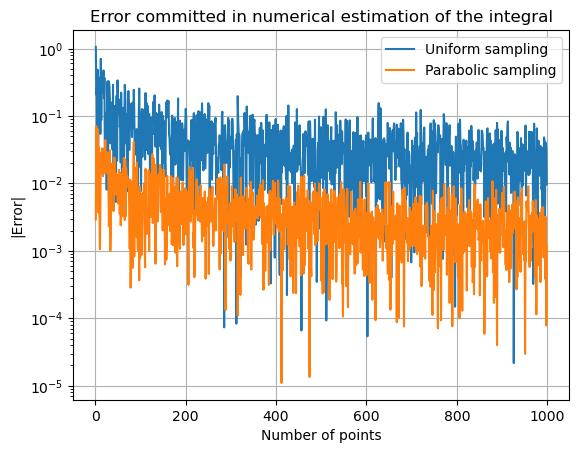

In [27]:
import matplotlib.pyplot as plt

plt.plot(step_number,abs(errors), label="Uniform sampling")
plt.plot(step_number,abs(errors_parabolic), label="Parabolic sampling")
plt.yscale('log')
plt.grid(1)
plt.legend()
plt.xlabel("Number of points")
plt.ylabel("|Error|")
plt.title("Error committed in numerical estimation of the integral")
plt.show()

In [2]:
def integrate_raindrop(function, intervall, N):
    """Integrator by raindrop method

    This function integrates the given function with the raindrop method. You must specify the function to be integrated, the intervall of integration and the number of points you want to extract"""
    import numpy as np

    #First I find the codomain of the function. The level of precision in doing so depends on the number of steps one wants to take
    x_scan = np.linspace(intervall[0],intervall[1], num=N*10)
    y_scan = np.zeros(len(x_scan))
    i = 0
    for x in x_scan:
        y_scan[i] = function(x_scan[i])
        i += 1
    codomain = (min(y_scan), max(y_scan))

    x = np.random.uniform(intervall[0], intervall[1], N)
    y = np.random.uniform(codomain[0], codomain[1], N)
    integral = 0
    i = 0;
    while i < N:
        if y[i] < function(x[i]):
            integral += 1/N*(codomain[1]-codomain[0])*(intervall[1]-intervall[0])
        i += 1

    return integral

In [3]:
import numpy as np
import math as m
np.random.seed(27)

step_number = range(1,1000)
integrals = np.zeros(len(step_number))
errors = np.zeros(len(step_number))
i = 0
for N in step_number:
    integrals[i] = integrate_raindrop(m.sin, (0,np.pi), N)
    errors[i] = 2-integrals[i]
    i += 1

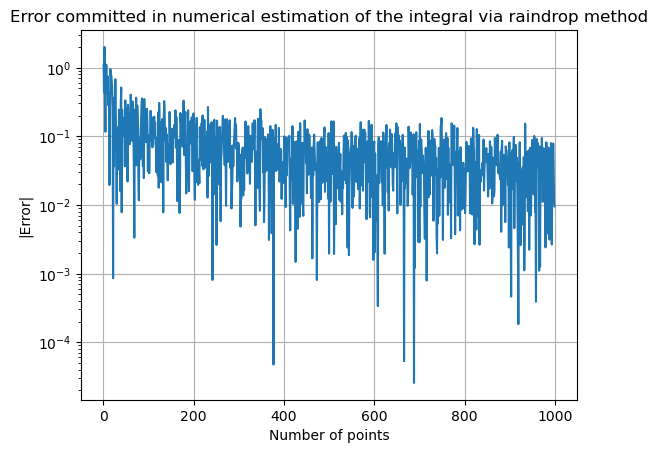

In [4]:
import matplotlib.pyplot as plt

plt.plot(step_number,abs(errors))
plt.yscale('log')
plt.grid(1)
plt.xlabel("Number of points")
plt.ylabel("|Error|")
plt.title("Error committed in numerical estimation of the integral via raindrop method")
plt.show()

## 3b) Importance sampling

Now we want to integrate numerically the function: 

$$I = \int_{0}^{2} e^{-x^2/2} \sin^2(5x) dx.$$.

Do it with different methods and compare the uncertainty of the result depending of the number of samples used for the integration. 

In particular, test 2 different functions used to propose candidate samples for the integration with **importance sampling**:
- a "bad" function, having a different shape (e.g. a uniform distribution)
- a good function, having a similar shape as the integrand


Which function gives you the best integration uncertainty? Does the integral converges in both cases or not?

In [27]:
def good_sampling(x):
    import math as m
    
    normalization = 1 - m.cos(10)*m.sin(10)/5
    return (m.sin(5*x))**2/normalization

In [2]:
def bad_sampling(x):
    import math as m
    
    normalization = 1 - m.cos(10+m.pi/2)*m.sin(10+m.pi/2)/5
    return (m.sin(5*x+m.pi/2))**2/normalization

In [3]:
def uniform_sampling(x):
    normalization = 2
    return 1/2;

In [4]:
def sampling_choice(name):
    import math as m
    
    if name == "good":
        normalization = 1 - m.cos(20)*m.sin(20)/10
        return (good_sampling,(0,1/normalization))
    if name == "bad":
        normalization = 1 - m.cos(20+m.pi/2)*m.sin(20+m.pi/2)/10
        return (bad_sampling,(0,1/normalization))
    if name == "uniform":
        return (uniform_sampling, (0,1/2))
    else:
        print("Sampling choice: Unknown sampling method")
        return 0

In [5]:
def sampler(sampling_method, intervall, N):
    """Generator of random numbers according to the specified sampling method

    It relies on raindrop method to generate the random numbers"""
    import numpy as np

    sampling_function, sampling_codomain = sampling_choice(sampling_method)

    random_numbers = np.zeros(N)
    i = 0; j = 0 #j is just to stop the while loop in case it is taking too much
    while (i<N)&(j<10*N):
        x = np.random.uniform(intervall[0], intervall[1])
        y = np.random.uniform(sampling_codomain[0], sampling_codomain[1])
        if y < sampling_function(x):
            random_numbers[i] = x
            i += 1
        j += 1

    if j == 10*N:
        print("Sampler: Too many cicles to generate the array of random numbers")
        return 0
    return random_numbers

In [6]:
def integrator(function, intervall, sampling_method, N):
    """Integrator with MC methods according to the specified sampling method

    The function needs the integrand, the integration intervall, the sampling method to be used and the number of points"""
    import numpy as np

    x = sampler(sampling_method, intervall, N)
    integral = 0
    i = 0
    sampling_distribution,_ = sampling_choice(sampling_method)
    while i < N:
        integral += function(x[i])/sampling_distribution(x[i])/N
        i += 1
    
    return integral

In [7]:
def integrand(x):
    import math as m
    
    f =m.exp(-x**2/2)*(m.sin(5*x))**2
    return f

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
np.random.seed(27)

max_points = 1000
points_number = range(1,max_points)
good    = np.zeros(max_points-1)
bad     = np.zeros(max_points-1)
uniform = np.zeros(max_points-1)
#print(len(points_number), len(good))

i = 0
for N in points_number:
    good[i]     = integrator(integrand, (0,2), "good"    , N)
    bad[i]      = integrator(integrand, (0,2), "bad"     , N)
    uniform[i]  = integrator(integrand, (0,2), "uniform" , N)
    i += 1

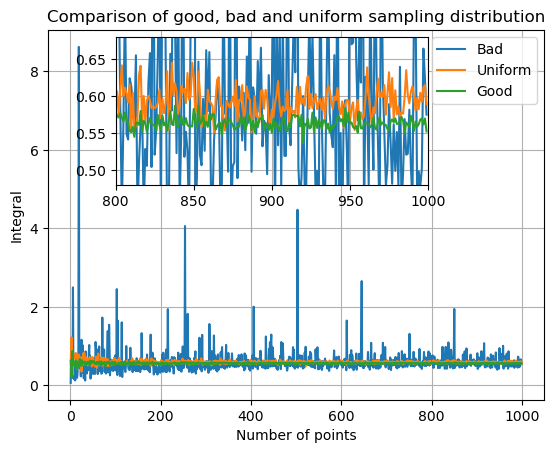

In [36]:
fig, ax = plt.subplots()
ax.plot(points_number, bad, label="Bad")
ax.plot(points_number, uniform, label="Uniform")
ax.plot(points_number, good, label="Good")
ax.grid(1)
plt.title("Comparison of good, bad and uniform sampling distribution")
plt.xlabel("Number of points")
plt.ylabel("Integral")
ax.legend()
ax_inset = inset_axes(ax, width="70%", height="50%", bbox_to_anchor=(-0.12, 0.2, 0.9, 0.8), bbox_transform=ax.transAxes)
ax_inset.plot(points_number, bad)
ax_inset.plot(points_number, uniform)
ax_inset.plot(points_number, good)
ax_inset.grid(1)
ax_inset.set_xlim(800,1000)
ax_inset.set_ylim(0.48,0.68)
plt.show()